In [53]:
import numpy as np
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import accuracy_score, f1_score, top_k_accuracy_score, auc
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from lightgbm.callback import early_stopping
import seaborn as sns
from sklearn.linear_model import LogisticRegression

# Pre-proccessing

In [3]:
TRAIN_LOCS_KEY = 'train_locs'
TRAIN_IDS_KEY = 'train_ids'
TAXON_IDS_KEY = 'taxon_ids'
TAXON_NAME_KEY = 'taxon_names'

TEST_LOCS_KEY = 'test_locs'
TEST_IDS_KEY = 'test_pos_inds'

Reading the file:

In [4]:
filepath = os.path.join(os.getcwd(), 'species_train.npz')
data = np.load(filepath, allow_pickle=True)
train_locs = data[TRAIN_LOCS_KEY]
train_ids = data[TRAIN_IDS_KEY]
taxon_ids = data[TAXON_IDS_KEY]
taxon_names = data[TAXON_NAME_KEY]

Reading the test file:

In [5]:
test_filepath = os.path.join(os.getcwd(), 'species_test.npz')
test_data = np.load(test_filepath, allow_pickle=True)
test_locs = test_data[TEST_LOCS_KEY]
test_ids = test_data[TEST_IDS_KEY]

Mapping the taxon ids to taxon latin names: 

In [6]:
species_ids_names = dict(zip(data['taxon_ids'], data['taxon_names']))  # latin names of species 

Create pandas Dataframe from the train data: 

In [7]:
df = pd.DataFrame({
    'latitude': train_locs[:, 0],
    'longitude': train_locs[:, 1], 
    'taxon_id': data[TRAIN_IDS_KEY]
})
df['taxon_name'] = [species_ids_names[id] for id in data[TRAIN_IDS_KEY].astype(int)]
df.head()

,latitude,longitude,taxon_id,taxon_name
0,-18.286728,143.481247,31529,Lophognathus gilberti
1,-13.099798,130.783646,31529,Lophognathus gilberti
2,-13.965274,131.695145,31529,Lophognathus gilberti
3,-12.853950,132.800507,31529,Lophognathus gilberti
4,-12.196790,134.279327,31529,Lophognathus gilberti


Create pandas Dataframe from the test data: 

In [8]:
rows = [
    [test_locs[loc_id][0], test_locs[loc_id][1], taxon_id]
    for taxon_id, loc_ids in zip(taxon_ids, test_ids)
    for loc_id in loc_ids
]

In [9]:
test_df = pd.DataFrame(rows, columns=["latitude", "longitude", "taxon_id"])
test_df['taxon_name'] = [species_ids_names[id] for id in test_df["taxon_id"].astype(int)]
test_df.head()

,latitude,longitude,taxon_id,taxon_name
0,-19.884237,126.052979,31529,Lophognathus gilberti
1,-20.219316,124.723953,31529,Lophognathus gilberti
2,-20.053690,125.386505,31529,Lophognathus gilberti
3,-19.973000,126.462440,31529,Lophognathus gilberti
4,-19.962839,124.980362,31529,Lophognathus gilberti


In [10]:
test_df.shape

(1706646, 4)

Data Cleanining: 

<small>1. Check for missing or invalid coordinates:</small>

In [11]:
df = df.dropna(subset=['latitude', 'longitude'])
test_df = test_df.dropna(subset=['latitude', 'longitude'])
df = df[(df['latitude'].between(-90, 90)) & (df['longitude'].between(-180, 180))]
test_df = test_df[(test_df['latitude'].between(-90, 90)) & (test_df['longitude'].between(-180, 180))]
df.shape, test_df.shape

((272037, 4), (1706646, 4))

<small>2. Remove any duplicates or nearly duplicates (observations that are extremely close):</small>

In [12]:
df['lat_rounded'] = df['latitude'].round(5)
df['lon_rounded'] = df['longitude'].round(5)
test_df['lat_rounded'] = test_df['latitude'].round(5)
test_df['lon_rounded'] = test_df['longitude'].round(5)

In [13]:
df = df.drop_duplicates(subset=['lat_rounded', 'lon_rounded', 'taxon_id'])
test_df = test_df.drop_duplicates(subset=['lat_rounded', 'lon_rounded', 'taxon_id'])
df.shape, test_df.shape

((251822, 6), (1706646, 6))

<small>4. Validate species IDs: </small>

In [14]:
df['taxon_id'].isna().sum(), test_df['taxon_id'].isna().sum()

(np.int64(0), np.int64(0))

<small>5. Only keep birds:</small>

<small>Note: Only run the next 2 blocks one time as they take a few seconds:</small>

In [15]:
taxa = pd.read_csv('taxa.csv')
birds = taxa[taxa['class'] == 'Aves']
bird_taxon_ids = set(birds['id'])
len(bird_taxon_ids)

35102

In [16]:
df = df[df['taxon_id'].isin(bird_taxon_ids)].copy()
test_df = test_df[test_df['taxon_id'].isin(bird_taxon_ids)].copy()
df.shape, test_df.shape

((162642, 6), (1323320, 6))

<small>6. Convert to categorical labels:</small>

In [17]:
le = LabelEncoder()
le.fit(pd.concat([df['taxon_id'], test_df['taxon_id']]))
df['label'] = le.transform(df['taxon_id'])
test_df['label'] = le.transform(test_df['taxon_id'])

<small>7. Append the climate data</small>

In [18]:
import rasterio
import numpy as np
import os

base_dir = os.getcwd()  # assumes folders are in the same directory as this notebook

def load_stack(folder_name):
    folder = os.path.join(base_dir, folder_name)
    files = sorted([os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".tif")])
    if len(files) != 12:
        raise RuntimeError(f"Expected 12 GeoTIFFs in {folder_name}, found {len(files)}.")
    layers = []
    transform = None
    for f in files:
        with rasterio.open(f) as src:
            layers.append(src.read(1))
            transform = src.transform  # all months share the same transform
    return np.stack(layers), transform  # shape: (12, H, W), and affine transform

tmin, transform = load_stack("wc2.1_2.5m_tmin")
tmax, _         = load_stack("wc2.1_2.5m_tmax")
prec, _         = load_stack("wc2.1_2.5m_prec")

print("Stacks loaded. Shapes:",
      "tmin", tmin.shape, "tmax", tmax.shape, "prec", prec.shape)
print("Transform:", transform)

Stacks loaded. Shapes: tmin (12, 4320, 8640) tmax (12, 4320, 8640) prec (12, 4320, 8640)
Transform: | 0.04, 0.00,-180.00|
| 0.00,-0.04, 90.00|
| 0.00, 0.00, 1.00|


In [19]:
#Cleaning the data again as the precipitation values are very large, so I'll normalize them
from rasterio.transform import rowcol
import numpy as np

def get_climate_for_points(df, transform, tmin, tmax, prec, lat_col="latitude", lon_col="longitude"):
    # Convert lat/lon → raster indices
    rows, cols = rowcol(transform, df[lon_col].values, df[lat_col].values)
    rows = np.clip(rows, 0, tmin.shape[1]-1)
    cols = np.clip(cols, 0, tmin.shape[2]-1)

    # Helper: clean up weird values (NoData etc.)
    def clean(arr):
        arr = arr.astype(float)
        arr[arr > 1e4] = np.nan  # remove unrealistic large values
        return arr

    tmin = clean(tmin)
    tmax = clean(tmax)
    prec = clean(prec)

    # Extract values and average across 12 months safely
    tmin_mean = np.nanmean(tmin[:, rows, cols], axis=0)
    tmax_mean = np.nanmean(tmax[:, rows, cols], axis=0)
    prec_mean = np.nanmean(prec[:, rows, cols], axis=0)

    return tmin_mean, tmax_mean, prec_mean

In [20]:
tmin_avg, tmax_avg, prec_avg = get_climate_for_points(df, transform, tmin, tmax, prec)

In [21]:
test_tmin_avg, test_tmax_avg, test_prec_avg = get_climate_for_points(test_df, transform, tmin, tmax, prec)

In [22]:
df["Tmin_avg"] = tmin_avg
df["Tmax_avg"] = tmax_avg
df["Prec_avg"] = prec_avg

df[["latitude","longitude","Tmin_avg","Tmax_avg","Prec_avg"]].head()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg
53,21.086105,-86.852867,20.967000,31.436000,103.416667
54,19.186003,-96.199600,19.327333,31.831333,117.833333
55,17.538877,-89.113724,19.496333,30.576333,125.583333
56,20.648556,-105.220955,19.674123,31.835527,87.750000
57,18.409698,-95.096657,20.515000,29.086000,156.750000


In [23]:
test_df["Tmin_avg"] = test_tmin_avg
test_df["Tmax_avg"] = test_tmax_avg
test_df["Prec_avg"] = test_prec_avg

test_df[["latitude","longitude","Tmin_avg","Tmax_avg","Prec_avg"]].head()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg
784,19.289352,-89.842888,1.885033e+01,3.272100e+01,91.750000
785,20.777590,-88.534241,1.882467e+01,3.272433e+01,103.833333
786,21.513868,-86.804565,2.165833e+01,3.071667e+01,100.250000
787,18.710384,-94.898964,-3.400000e+38,-3.400000e+38,-32768.000000
788,21.509193,-88.522995,1.973447e+01,3.149773e+01,73.250000


In [24]:
out_path = "bird_species_rerun_with_averaged_climate.csv"
df.to_csv(out_path, index=False)
out_path, df.shape

('bird_species_rerun_with_averaged_climate.csv', (162642, 10))

In [25]:
out_path = "test_bird_species_rerun_with_averaged_climate.csv"
test_df.to_csv(out_path, index=False)
out_path, test_df.shape

('test_bird_species_rerun_with_averaged_climate.csv', (1323320, 10))

In [26]:
df = pd.read_csv('bird_species_rerun_with_averaged_climate.csv')

In [27]:
test_df = pd.read_csv('test_bird_species_rerun_with_averaged_climate.csv')

<small>8. Clean the climate data</small>

In [28]:
df['Tmin_avg'] = df['Tmin_avg'].mask(df['Tmin_avg'] < -1e+30, np.nan)
df['Tmax_avg'] = df['Tmax_avg'].mask(df['Tmax_avg'] < -1e+30, np.nan)
df['Prec_avg'] = df['Prec_avg'].mask(df['Prec_avg'] < 0, np.nan)
print(f"Shape with nan data: {df.shape}")
df = df.dropna(subset=['Tmin_avg', 'Tmax_avg', 'Prec_avg'])
print(f"Shape without nan data: {df.shape}")

Shape with nan data: (162642, 10)
Shape without nan data: (161432, 10)


In [29]:
len(test_df)

1323320

In [30]:
test_df['Tmin_avg'] = test_df['Tmin_avg'].mask(test_df['Tmin_avg'] < -1e+30, np.nan)
test_df['Tmax_avg'] = test_df['Tmax_avg'].mask(test_df['Tmax_avg'] < -1e+30, np.nan)
test_df['Prec_avg'] = test_df['Prec_avg'].mask(test_df['Prec_avg'] < 0, np.nan)
print(f"Shape with nan data: {test_df.shape}")
test_df = test_df.dropna(subset=['Tmin_avg', 'Tmax_avg', 'Prec_avg'])
print(f"Shape without nan data: {test_df.shape}")

Shape with nan data: (1323320, 10)
Shape without nan data: (928354, 10)


<small>Note: mention in the report that we lost a lot of data because of removing NaN temperature, in the ociens mainly.</small>

In [31]:
(df['Tmax_avg'] < df['Tmin_avg']).sum(), (test_df['Tmax_avg'] < test_df['Tmin_avg']).sum()

(np.int64(0), np.int64(0))

<small>Add sin feature to capture circularity</small>

In [32]:
df['lat_sin'] = np.sin(np.deg2rad(df['latitude']))
df['lat_cos'] = np.cos(np.deg2rad(df['latitude']))
df['lon_sin'] = np.sin(np.deg2rad(df['longitude']))
df['lon_cos'] = np.cos(np.deg2rad(df['longitude']))

In [33]:
test_df['lat_sin'] = np.sin(np.deg2rad(test_df['latitude']))
test_df['lat_cos'] = np.cos(np.deg2rad(test_df['latitude']))
test_df['lon_sin'] = np.sin(np.deg2rad(test_df['longitude']))
test_df['lon_cos'] = np.cos(np.deg2rad(test_df['longitude']))

In [34]:
df.shape, test_df.shape

((161432, 14), (928354, 14))

<small>9. Split the data to x and y and normalize the climate features</small>

In [35]:
X_data = df.drop(columns=['taxon_id', 'taxon_name', 'lat_rounded', 'lon_rounded', 'label'])
y_data = df['label']
climate_features = ['Tmin_avg', 'Tmax_avg', 'Prec_avg']
non_scaled_features = ['latitude', 'longitude']
# scale climate 
scaler = StandardScaler()
scaler.fit(X_data[climate_features])
X_scaled = X_data.copy()
X_scaled[climate_features] = scaler.transform(X_data[climate_features])
X_scaled.describe()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg,lat_sin,lat_cos,lon_sin,lon_cos
count,161432.000000,161432.000000,1.614320e+05,1.614320e+05,1.614320e+05,161432.000000,161432.000000,161432.000000,161432.000000
mean,14.827329,-8.036515,-6.197310e-17,2.929638e-16,5.633918e-18,0.230808,0.820155,-0.203034,0.042523
std,31.900029,95.705462,1.000003e+00,1.000003e+00,1.000003e+00,0.509097,0.122050,0.770315,0.602984
min,-75.284950,-178.060320,-6.699036e+00,-6.690300e+00,-1.635481e+00,-0.967201,0.254012,-1.000000,-0.999791
25%,-21.050622,-96.105056,-6.488781e-01,-7.633616e-01,-6.553056e-01,-0.359193,0.747490,-0.968077,-0.459039
50%,26.165924,-43.440056,1.560563e-02,1.265317e-01,-1.806941e-01,0.440972,0.831109,-0.673665,0.067571
75%,40.959681,75.385002,6.814487e-01,7.350146e-01,3.936545e-01,0.655528,0.914683,0.524633,0.545473
max,72.515430,178.827590,2.250907e+00,2.213666e+00,1.319785e+01,0.953798,1.000000,1.000000,1.000000


In [36]:
X_test = test_df.drop(columns=['taxon_id', 'taxon_name', 'lat_rounded', 'lon_rounded', 'label'])
y_test = test_df['label']
climate_features = ['Tmin_avg', 'Tmax_avg', 'Prec_avg']
non_scaled_features = ['latitude', 'longitude']
# scale climate 
X_test_scaled = X_test.copy()
X_test_scaled[climate_features] = scaler.transform(X_test[climate_features])
X_test_scaled.describe()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg,lat_sin,lat_cos,lon_sin,lon_cos
count,928354.000000,928354.000000,928354.000000,928354.000000,928354.000000,928354.000000,928354.000000,928354.000000,928354.000000
mean,13.171677,13.497898,0.183610,0.289493,-0.008040,0.198286,0.853137,0.094081,0.314364
std,29.127638,77.380268,1.432959,1.412140,1.242831,0.455790,0.158418,0.745243,0.580464
min,-85.600830,-179.933670,-6.928313,-7.189774,-1.635481,-0.997054,0.076705,-1.000000,-1.000000
25%,-12.422070,-59.177242,-0.792492,-0.690674,-0.923564,-0.215112,0.773541,-0.837545,-0.177202
50%,11.103984,23.309443,0.622043,0.861617,-0.350935,0.192590,0.913240,0.389406,0.445380
75%,38.710465,74.511734,1.357427,1.342591,0.594849,0.625385,0.979165,0.720192,0.853618
max,82.845260,179.994780,2.595104,2.364347,12.102457,0.992213,1.000000,1.000000,1.000000


<small>9. Split to train and validation sets</small>

In [37]:
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_data,
                                                  test_size=0.2,
                                                  random_state=42, 
                                                  stratify=y_data)

X_train.to_csv('X_train.csv', index=False)
X_val.to_csv('X_val.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_val.to_csv('y_val.csv', index=False)

# Exploratory Data Analysis:

check skewness

In [39]:
print("Lat skewness:", df['latitude'].skew())
print("Long skewness:", df['longitude'].skew())

Lat skewness: -0.4843194974691385
Long skewness: 0.44562316816550696


check imbalance

# of unique species: 285
count Most common speciest: 1963
count Least common species: 42
Imbalance ratio (max:min): 46.73809523809524


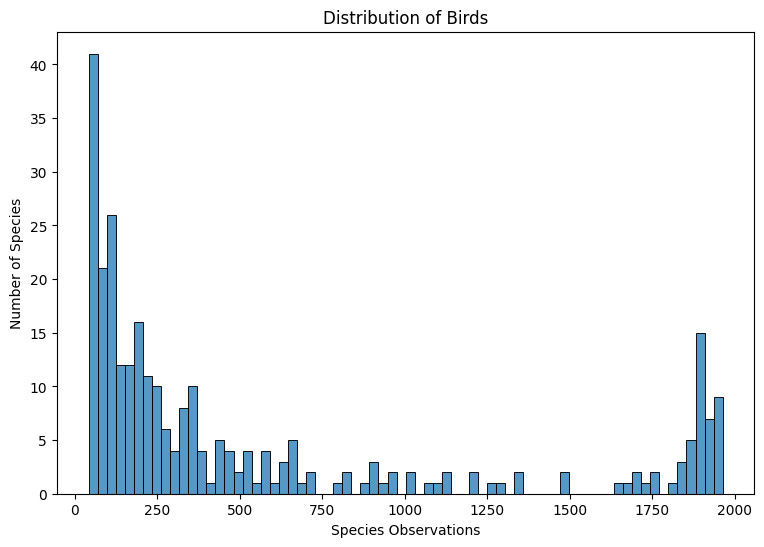

In [41]:
#dataset balance
species_counts = df['taxon_id'].value_counts()

print("# of unique species:", df['taxon_id'].nunique())
print("count Most common speciest:", species_counts.max())
print("count Least common species:", species_counts.min())
imbalance_ratio = species_counts.max() / species_counts.min()
print("Imbalance ratio (max:min):", imbalance_ratio)
plt.figure(figsize=(9,6))
sns.histplot(species_counts, bins=70)
plt.title('Distribution of Birds')
plt.xlabel('Species Observations')
plt.ylabel('Number of Species')
plt.show()

Correlation analysis

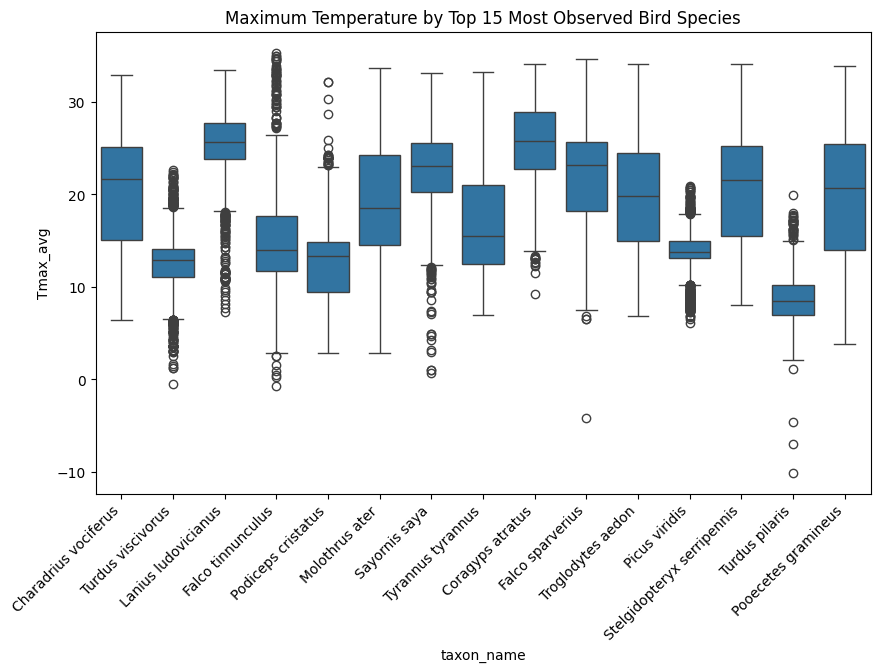

In [42]:
# choose the top 15 species to do the analysis on MAX temp
top_species = df['taxon_name'].value_counts().head(15).index
df_top15 = df[df['taxon_name'].isin(top_species)]
plt.figure(figsize=(10,6))
sns.boxplot(x='taxon_name', y='Tmax_avg', data=df_top15)
plt.xticks(rotation=45, ha='right')
plt.title('Maximum Temperature by Top 15 Most Observed Bird Species')
plt.show()

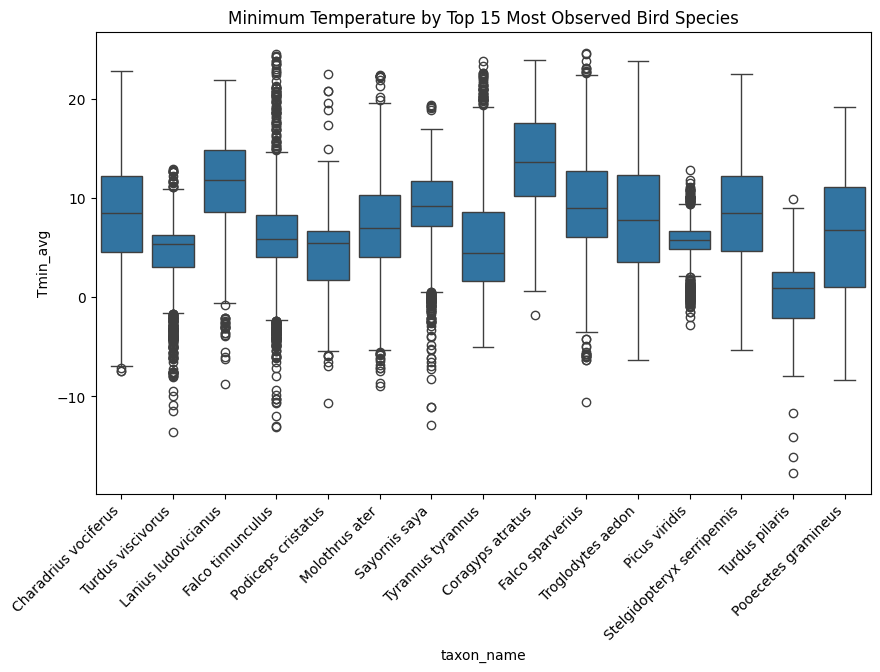

In [43]:
# choose the top 15 species to do the analysis on Min Temp
top_species = df['taxon_name'].value_counts().head(15).index
df_top15 = df[df['taxon_name'].isin(top_species)]
plt.figure(figsize=(10,6))
sns.boxplot(x='taxon_name', y='Tmin_avg', data=df_top15)
plt.xticks(rotation=45, ha='right')
plt.title('Minimum Temperature by Top 15 Most Observed Bird Species')
plt.show()

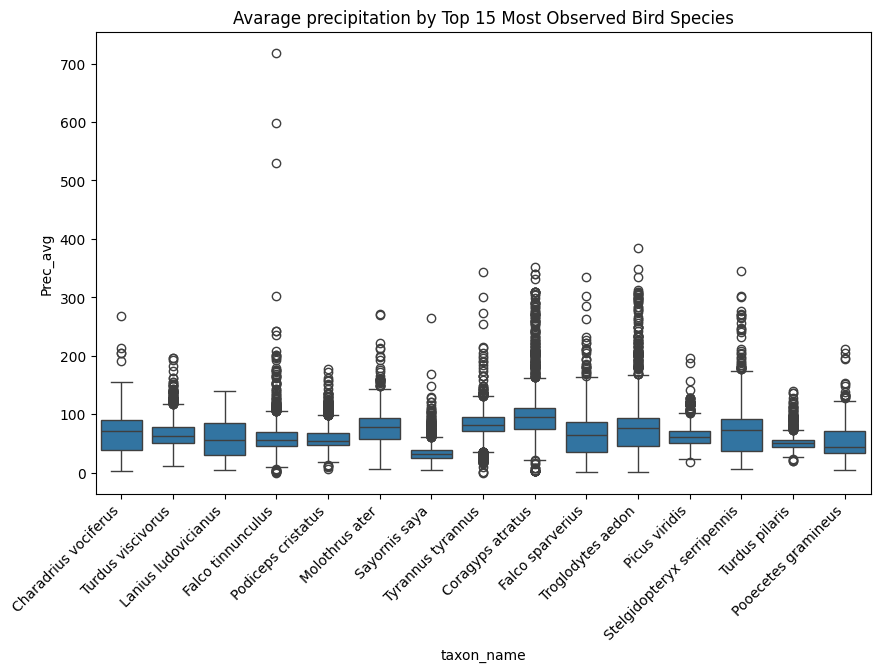

In [44]:
# choose the top 15 species to do the analysis on Avarage precipitation
top_species = df['taxon_name'].value_counts().head(15).index
df_top15 = df[df['taxon_name'].isin(top_species)]
plt.figure(figsize=(10,6))
sns.boxplot(x='taxon_name', y='Prec_avg', data=df_top15)
plt.xticks(rotation=45, ha='right')
plt.title('Avarage precipitation by Top 15 Most Observed Bird Species')
plt.show()

feature-feature relationships

Text(0.5, 1.0, 'Correlation Matrix of Climatic Variables')

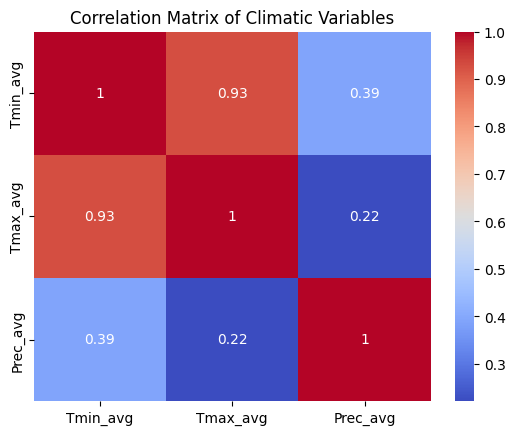

In [45]:
corr = df[['Tmin_avg', 'Tmax_avg', 'Prec_avg']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Climatic Variables')

ANOVA F-scores

In [47]:
from sklearn.feature_selection import f_classif
# Encode species numerically
X = df[['Tmin_avg', 'Tmax_avg']]
y = df['taxon_id']

y_enc = LabelEncoder().fit_transform(y)

# ANOVA F-value
f_scores, p_values = f_classif(X, y_enc)
print("ANOVA F-scores:", f_scores)

ANOVA F-scores: [1305.56595792 1474.20493621]


In [48]:
df['lat_round'] = df['latitude'].round(1)
df['lon_round'] = df['longitude'].round(1)

abundance = df.groupby(['lat_round', 'lon_round']).size().reset_index(name='count')
abundance.head()

,lat_round,lon_round,count
0,-75.3,-102.7,1
1,-75.3,-0.1,1
2,-67.6,-68.1,1
3,-65.9,-66.2,1
4,-65.1,-64.0,2


Spatial Disterbution

C:\Users\hajir\AppData\Local\Temp\ipykernel_6760\2466296275.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, 'Spatial Distribution by Top 5 Bird Species')

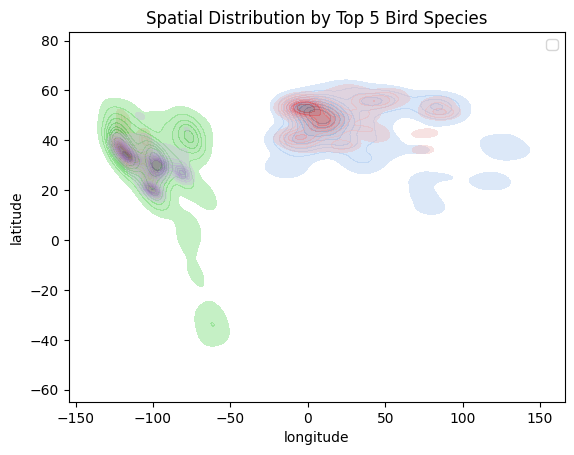

In [49]:
top_species = df['taxon_name'].value_counts().head(5).index
for species in top_species:
    subset = df[df['taxon_name'] == species]
    sns.kdeplot(x=subset['longitude'], y=subset['latitude'], fill=True, label=species, alpha=0.4)
plt.legend()
plt.title('Spatial Distribution by Top 5 Bird Species')

Top 15 species

In [50]:
# counts of all species
counts = df['taxon_name'].value_counts()

# pick top 15
top15 = counts.head(15)

# percentage of dataset represented by top 15 species
percentage = (top15.sum() / counts.sum()) * 100

print(f"Top 15 species represent {percentage:.2f}% of the total dataset.")

Top 15 species represent 18.01% of the total dataset.


# Models:

<small>Model 1: LightGBM<br> This model depends on decision tree and has hyperparameters</small>


In [ ]:
# Model 1 (a): LightGBM with probability distribution output
# Note to Maya: This is not very important model, Model 1 (b) is more important
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test_scaled, label=y_test)
boosting_types = ['gbdt']
num_leaves = [31]
max_depths = [-1]
for boosting_type in boosting_types: 
    for num_leaf in num_leaves: 
        for max_depth in max_depths: 
            params = {
                'objective': 'multiclass',
                'num_class': 285,
                'learning_rate': 0.05,
                'metric': 'multi_logloss',
                'boosting_type': "gbdt",
                'max_depth': 30, 
                'num_leaves': 31, 
                'lambda_l1': 0.5,
                'lambda_l2': 1.0, 
                'is_unbalance': True
            }
            clf = lgb.train(
                params,
                train_data,
                valid_sets=[test_data],
                num_boost_round=2000,
                callbacks= [early_stopping(stopping_rounds=100)]
            )
            y_pred_prob = clf.predict(X_test_scaled, num_iteration=clf.best_iteration)
            y_pred = y_pred_prob.argmax(axis=1)
            print("Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
# Note to Maya: If this doesn't work just comment it
print(f1_score(y_test, y_pred, average='macro'))
print("Top-5 acc", top_k_accuracy_score(y_test, y_pred_prob, k=5, labels=list(set(y_train))))
print("Top-7 acc", top_k_accuracy_score(y_test, y_pred_prob, k=7, labels=list(set(y_train))))
print("Top-10 acc", top_k_accuracy_score(y_test, y_pred_prob, k=10, labels=list(set(y_train))))

In [186]:
# Model 1 (b): LightGBM with vector binary output

In [39]:
train_df = X_train.copy()
train_df['label'] = y_train
grouped_train = (
    train_df.groupby(list(X_train.columns))['label']
    .apply(list)
    .reset_index(name='labels')
)

In [62]:
train_df = X_val.copy()
train_df['label'] = y_val
grouped_val = (
    train_df.groupby(list(X_val.columns))['label']
    .apply(list)
    .reset_index(name='labels')
)

In [40]:
grouped_train.head()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg,lat_sin,lat_cos,lon_sin,lon_cos,labels
0,-75.284950,-102.746760,-3.808437,-4.360072,-0.285590,-0.967201,0.254012,-0.975355,-0.220642,[202]
1,-75.250980,-0.071389,-6.699036,-6.690300,-1.494474,-0.967050,0.254585,-0.001246,0.999999,[202]
2,-67.566444,-68.129295,-2.445172,-3.109188,-0.971713,-0.924323,0.381612,-0.928027,0.372513,[202]
3,-65.889150,-66.195350,-2.298080,-3.007162,-0.418000,-0.912757,0.408503,-0.914927,0.403620,[202]
4,-65.063310,-64.039406,-2.333057,-3.051751,-0.096433,-0.906774,0.421617,-0.899095,0.437753,[202]


In [41]:
grouped_train.shape

(122166, 10)

In [63]:
grouped_val.head()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg,lat_sin,lat_cos,lon_sin,lon_cos,labels
0,-65.075900,-63.996357,-2.241169,-2.978719,-0.092994,-0.906867,0.421417,-0.898766,0.438428,[202]
1,-64.876114,-62.542420,-2.561603,-3.333969,-0.428318,-0.905392,0.424577,-0.887352,0.461092,[202]
2,-64.823880,-62.856915,-2.273834,-3.036636,-0.170376,-0.905004,0.425402,-0.889870,0.456214,[202]
3,-64.696686,-62.739140,-2.480519,-3.265628,-0.301067,-0.904058,0.427410,-0.888930,0.458042,[27]
4,-64.689300,-61.967083,-2.590112,-3.407331,-0.591680,-0.904003,0.427527,-0.882678,0.469979,[202]


In [64]:
grouped_val.shape

(31667, 10)

In [42]:
test_df = X_test_scaled.copy()
test_df['label'] = y_test
grouped_test = (
    test_df.groupby(list(X_test.columns))['label']
    .apply(list)
    .reset_index(name='labels')
)
grouped_test.shape

(75432, 10)

In [43]:
grouped_test[290: 300]

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg,lat_sin,lat_cos,lon_sin,lon_cos,labels
290,-69.531660,33.893047,-4.649422,-4.999933,-1.112721,-0.936866,0.349690,0.557644,0.830080,"[27, 28]"
291,-69.509710,-67.743520,-3.580448,-3.979311,-1.286401,-0.936732,0.350049,-0.925498,0.378753,"[27, 28]"
292,-69.483080,-69.881020,-3.970080,-4.315951,-1.135076,-0.936569,0.350484,-0.938980,0.343971,"[27, 28]"
293,-69.260826,68.967660,-3.847977,-4.427454,-1.135076,-0.935202,0.354114,0.933378,0.358895,"[202, 27, 28]"
294,-69.244560,-70.887570,-4.460877,-4.716619,-1.083488,-0.935102,0.354380,-0.944878,0.327423,[27]
295,-69.243250,-62.398620,-3.433829,-4.037443,-1.315635,-0.935093,0.354401,-0.886192,0.463317,"[202, 27, 28]"
296,-69.226600,158.234100,-3.536519,-4.371476,-1.252009,-0.934990,0.354673,0.370815,-0.928707,"[202, 27, 28]"
297,-69.208015,77.470505,-4.085506,-4.695692,-1.264046,-0.934875,0.354976,0.976184,0.216942,"[202, 27, 28]"
298,-69.194860,33.190598,-4.364435,-4.757293,-1.019862,-0.934794,0.355191,0.547426,0.836854,"[27, 28]"
299,-69.048870,-63.485900,-3.532068,-4.056594,-1.286401,-0.933886,0.357572,-0.894825,0.446418,"[202, 27, 28]"


In [ ]:
mlb = MultiLabelBinarizer(classes=range(285))
Y_train = mlb.fit_transform(grouped_train['labels'])
Y_test = mlb.transform(grouped_test['labels'])
X_train_ready = grouped_train.drop(columns=['labels'])
X_test_ready = grouped_test.drop(columns=['labels'])


In [65]:
Y_val = mlb.transform(grouped_val['labels'])
X_val_ready = grouped_val.drop(columns=['labels'])

In [45]:
X_train_ready_no_cos = X_train_ready.drop(columns=['lat_sin', 'lat_cos', 'lon_sin', 'lon_cos'])
X_test_ready_no_cos = X_test_ready.drop(columns=['lat_sin', 'lat_cos', 'lon_sin', 'lon_cos'])

X_train_ready.head()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg,lat_sin,lat_cos,lon_sin,lon_cos
0,-75.284950,-102.746760,-3.808437,-4.360072,-0.285590,-0.967201,0.254012,-0.975355,-0.220642
1,-75.250980,-0.071389,-6.699036,-6.690300,-1.494474,-0.967050,0.254585,-0.001246,0.999999
2,-67.566444,-68.129295,-2.445172,-3.109188,-0.971713,-0.924323,0.381612,-0.928027,0.372513
3,-65.889150,-66.195350,-2.298080,-3.007162,-0.418000,-0.912757,0.408503,-0.914927,0.403620
4,-65.063310,-64.039406,-2.333057,-3.051751,-0.096433,-0.906774,0.421617,-0.899095,0.437753


In [66]:
X_val_ready_no_cos = X_val_ready.drop(columns=['lat_sin', 'lat_cos', 'lon_sin', 'lon_cos'])

In [ ]:
from sklearn.multioutput import MultiOutputClassifier

base_model = lgb.LGBMClassifier(
    objective='binary',     # because each label is a binary classification
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    n_jobs=-1
)
multi_model = MultiOutputClassifier(base_model)
# Y_pred_proba = np.column_stack([p[:, 1] for p in Y_pred_proba])  # take probability of class 1 for each label
# Y_pred = (Y_pred_proba > 0.5).astype(int)


[LightGBM] [Info] Number of positive: 187, number of negative: 121979
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001194 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 122166, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001531 -> initscore=-6.480496
[LightGBM] [Info] Start training from score -6.480496
[LightGBM] [Info] Number of positive: 283, number of negative: 121883
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001176 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 122166, number of used features: 9
[LightGBM] [Info] [b

In [ ]:
multi_model.fit(X_train_ready, Y_train)
Y_pred_proba = multi_model.predict_proba(X_val_ready)

In [137]:
Y_pred_proba = multi_model.predict_proba(X_test_ready)

In [138]:
Y_pred_proba_list = np.array(Y_pred_proba)[:, :, 1].T

In [139]:
Y_pred_proba_list.shape

(75432, 285)

In [ ]:
# tuning the threshold
from sklearn.metrics import f1_score
thresholds = np.linspace(0.05, 0.9, 9)
for t in thresholds:
    y_pred = (Y_pred_proba_list >= t).astype(int)
    print(f"Threshold {t:.1f} → F1 (micro): {f1_score(Y_val, y_pred, average='micro'):.4f}")


Threshold 0.1 → F1 (micro): 0.2425
Threshold 0.2 → F1 (micro): 0.3270
Threshold 0.3 → F1 (micro): 0.3173
Threshold 0.4 → F1 (micro): 0.2802
Threshold 0.5 → F1 (micro): 0.2379
Threshold 0.6 → F1 (micro): 0.1935
Threshold 0.7 → F1 (micro): 0.1556
Threshold 0.8 → F1 (micro): 0.1153
Threshold 0.9 → F1 (micro): 0.0794


In [ ]:
best_thresholds = []
for i in range(Y_val.shape[1]):
    best_t, best_f1 = 0, 0
    for t in np.linspace(0.1, 0.9, 9):
        f1 = f1_score(Y_val[:, i], (Y_pred_proba_list[:, i] >= t).astype(int))
        if f1 > best_f1:
            best_t = t
            best_f1 = f1
    best_thresholds.append(best_t)

Y_pred = (Y_pred_proba_list >= best_thresholds).astype(int)


In [128]:
my_thresholds = [0.2]
for thresold in my_thresholds:
    print(f"threshold: {thresold}")
    Y_pred = (Y_pred_proba >= thresold).astype(int)
    micro_f1 = f1_score(Y_test, Y_pred, average='micro')
    macro_f1 = f1_score(Y_test, Y_pred, average='macro')
    samples_f1 = f1_score(Y_test, Y_pred, average='samples')
    print("Micro F1:", micro_f1)
    print("Macro F1:", macro_f1)
    print("Samples F1:", samples_f1)

threshold: 0.2
Micro F1: 0.1524552027186267
Macro F1: 0.15576338254853528
Samples F1: 0.1975183872284314


In [144]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

roc_auc = roc_auc_score(Y_test, Y_pred_proba_list, average='macro')
avg_prec = average_precision_score(Y_test, Y_pred_proba_list, average='macro')

print("ROC-AUC:", roc_auc)
print("Average Precision:", avg_prec)


ROC-AUC: 0.8845609542816047
Average Precision: 0.5573803295697065


In [ ]:
#plot roc curve with some help from chatgpt
def plot_roc_curves(Y_true, Y_pred_proba, dataset_name="Test"):
    """
    Plots ROC curves for the top 5 most frequent labels + a macro-average ROC curve.
    
    Args:
        Y_true (ndarray): True binary labels, shape (n_samples, n_classes)
        Y_pred_proba (ndarray): Predicted probabilities, shape (n_samples, n_classes)
        dataset_name (str): 'Validation' or 'Test' for plot title
    """
    # --- 1️⃣ Find top 5 most frequent labels ---
    label_freq = np.sum(Y_true, axis=0)
    top5_idx = np.argsort(label_freq)[-5:][::-1]

    print(f"Top 5 most frequent label indices ({dataset_name} set):", top5_idx)

    # --- 2️⃣ Plot ROC curves for top 5 labels ---
    plt.figure(figsize=(8, 6))
    for i in top5_idx:
        fpr, tpr, _ = roc_curve(Y_true[:, i], Y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves for Top 5 Most Frequent Classes ({dataset_name} Set)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- 3️⃣ Compute and plot macro-average ROC curve ---
    all_fpr = np.unique(np.concatenate([
        roc_curve(Y_true[:, i], Y_pred_proba[:, i])[0] for i in range(Y_true.shape[1])
    ]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(Y_true.shape[1]):
        fpr, tpr, _ = roc_curve(Y_true[:, i], Y_pred_proba[:, i])
        mean_tpr += np.interp(all_fpr, fpr, tpr)

    mean_tpr /= Y_true.shape[1]
    roc_auc_macro = auc(all_fpr, mean_tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(all_fpr, mean_tpr, color='blue', lw=2,
             label=f'Macro-average (AUC = {roc_auc_macro:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Macro-average ROC Curve ({dataset_name} Set)')
    plt.legend()
    plt.grid(True)
    plt.show()


Top 5 most frequent label indices (Test set): [257 175 238 154  29]


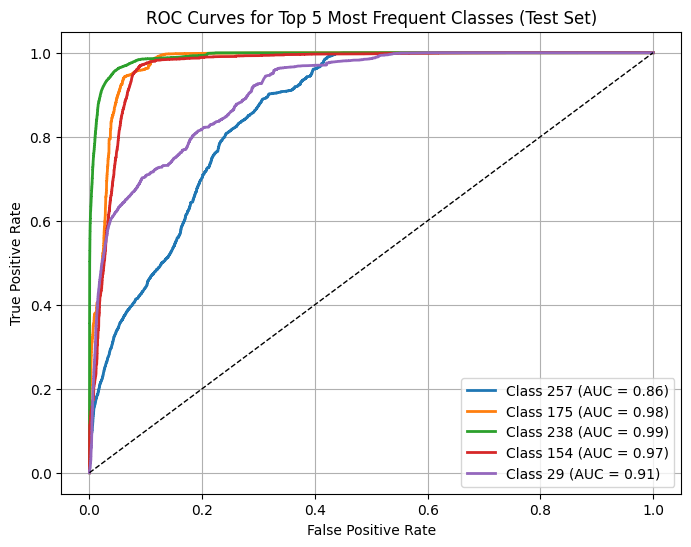

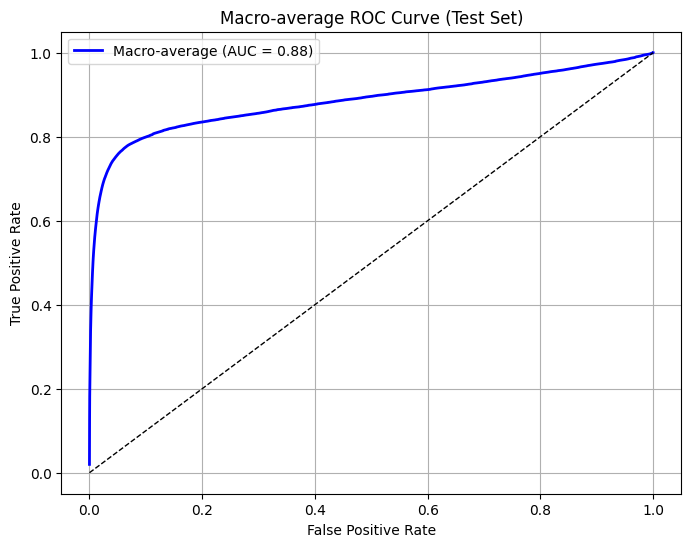

In [146]:
plot_roc_curves(Y_test, Y_pred_proba_list)

In [150]:
def top_k_labels_for_sample(y_pred_proba, k=5, label_names=None):
    """
    Returns the indices (and optionally names) of the top-k predicted labels for a single sample.

    Args:
        y_pred_proba (array-like): 1D array of predicted probabilities for one sample (shape: n_classes).
        k (int): Number of top labels to return.
        label_names (list, optional): List of label names corresponding to each class index.

    Returns:
        top_indices (ndarray): Indices of top-k labels.
        top_scores (ndarray): Their corresponding probabilities.
        top_labels (list, optional): Label names (if provided).
    """
    y_pred_proba = np.array(y_pred_proba)
    top_indices = np.argsort(y_pred_proba)[::-1][:k]
    top_scores = y_pred_proba[top_indices]
    
    if label_names is not None:
        top_labels = [label_names[i] for i in top_indices]
        return top_indices, top_scores, top_labels
    
    return top_indices, top_scores

In [183]:
x = 789
k = 5
actual_labels = true_indices = np.where(Y_test[x] == 1)[0]
print(f"Actual labels are: {actual_labels}")
prop_lis_for_x = Y_pred_proba_list[x]
predicted_labels, predicted_score = top_k_labels_for_sample(prop_lis_for_x, k=5)
print(f"Top {k} predicted labels are:")
for (predicted_label, predicted_score) in zip(predicted_labels, predicted_score) :
    print(f"{predicted_label}: {predicted_score}")

Actual labels are: [ 36  62  66 185 197]
Top 5 predicted labels are:
62: 0.999840119437172
197: 0.033401037426703035
36: 0.026130145688081217
66: 0.01741580126888945
185: 0.0029209694049191115


model 2: logistic regression

In [54]:
log_reg = LogisticRegression(solver='saga', max_iter=800, tol=1e-3,
                             class_weight='balanced', C=5.0, n_jobs=-1)

In [55]:
# Train (fit) the model
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.001
,C,5.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'saga'
,max_iter,800
,multi_class,'deprecated'


In [56]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = log_reg.predict(X_val)
print("Train acc:", log_reg.score(X_train, y_train))
print("Val  acc:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred, zero_division=0))

Train acc: 0.15237910875372643
Val  acc: 0.15204261777185865
              precision    recall  f1-score   support

           0       0.12      0.19      0.14        47
           1       0.17      0.56      0.26        71
           2       0.00      0.00      0.00       227
           3       0.31      0.85      0.45        13
           4       0.02      0.20      0.04        10
           5       0.21      0.44      0.29        16
           6       0.22      0.70      0.34       375
           7       0.08      0.42      0.13       106
           8       0.03      1.00      0.05        13
           9       0.08      0.40      0.13        10
          10       0.12      0.81      0.21        64
          11       0.07      0.03      0.04        68
          12       0.10      0.36      0.15        87
          13       0.00      0.00      0.00       137
          14       0.11      0.02      0.04        43
          15       0.06      0.10      0.07        42
          16       0

In [57]:
y_test_pred = log_reg.predict(X_test_scaled)
y_test_proba = log_reg.predict_proba(X_test_scaled)

In [58]:
print("Test accuracy:", accuracy_score(y_test, y_test_pred))
print("Top-5 accuracy:", top_k_accuracy_score(y_test, y_test_proba, k=5))
print("\nClassification Report (Test):\n")
print(classification_report(y_test, y_test_pred, zero_division=0))

Test accuracy: 0.05421315575739427
Top-5 accuracy: 0.23988801685563912

Classification Report (Test):

              precision    recall  f1-score   support

           0       0.03      0.04      0.04       593
           1       0.07      0.13      0.09      2217
           2       0.00      0.00      0.00      2877
           3       0.06      0.59      0.11       685
           4       0.07      0.09      0.08       791
           5       0.03      0.01      0.01       625
           6       0.08      0.20      0.11      4860
           7       0.09      0.35      0.14      6866
           8       0.01      0.59      0.03       253
           9       0.04      0.06      0.05      2990
          10       0.03      0.63      0.06       814
          11       0.03      0.03      0.03      3987
          12       0.03      0.01      0.01      1643
          13       0.03      0.00      0.00      1489
          14       0.03      0.01      0.02       277
          15       0.03      0.0

In [ ]:
# Model 3: